# Fraud Detection System

This notebook develops a fraud detection system for financial transactions.

Objectives:
- detect fraudulent transactions
- handle severe class imbalance
- identify anomalous behaviors
- build explainable fraud detection models
- support real-time risk monitoring

In [1]:
# ========================
# Fraud Detection Imports
# ========================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# ========================
# Display Settings
# ========================

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.float_format",
    "{:.4f}".format
)

sns.set_style("whitegrid")
# ========================
# Reproducibility
# ========================

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

In [3]:
# ========================
# Load Dataset
# ========================

DATA_PATH = Path(
    "C:\\Users\\meytb\\finshield-ai\\data\\fraud\\creditcard.csv"
)

df = pd.read_csv(DATA_PATH)

print(
    f"Dataset Shape: {df.shape}"
)

Dataset Shape: (284807, 31)


In [4]:
# ========================
# Dataset Preview
# ========================

df.head()
df.info()

missing_values = (
    
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_values = (
    missing_values[
        missing_values > 0
    ]
)

print(missing_values)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

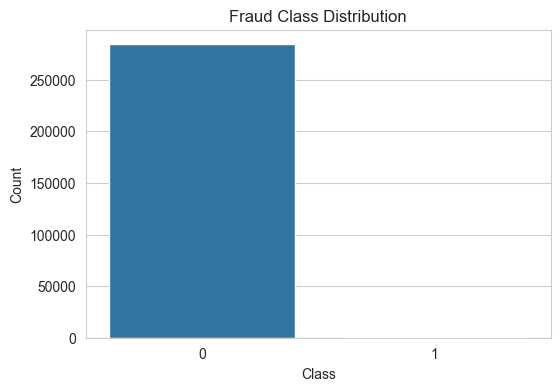

Class
0    284315
1       492
Name: count, dtype: int64


In [8]:
# ========================
# Fraud Count Plot
# ========================

plt.figure(figsize=(6,4))

sns.countplot(
    x=df["Class"]
)

plt.title(
    "Fraud Class Distribution"
)

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()
print(df["Class"].value_counts())

In [6]:
# ========================
# Transaction Amount
# ========================

df["Amount"].describe()

count   284807.0000
mean        88.3496
std        250.1201
min          0.0000
25%          5.6000
50%         22.0000
75%         77.1650
max      25691.1600
Name: Amount, dtype: float64

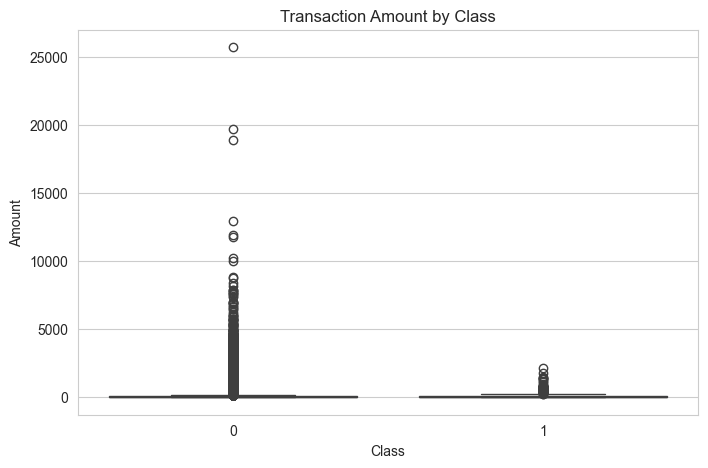

In [9]:
# ========================
# Fraud vs Non-Fraud
# ========================

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.title(
    "Transaction Amount by Class"
)

plt.show()

# 2. Fraud EDA & Feature Engineering

This section:
- explores transaction patterns
- analyzes fraud behavior
- engineers fraud-related features
- prepares the dataset for modeling

Combien de transactions ont eu lieu à chaque moment des 48h couvertes par le dataset?


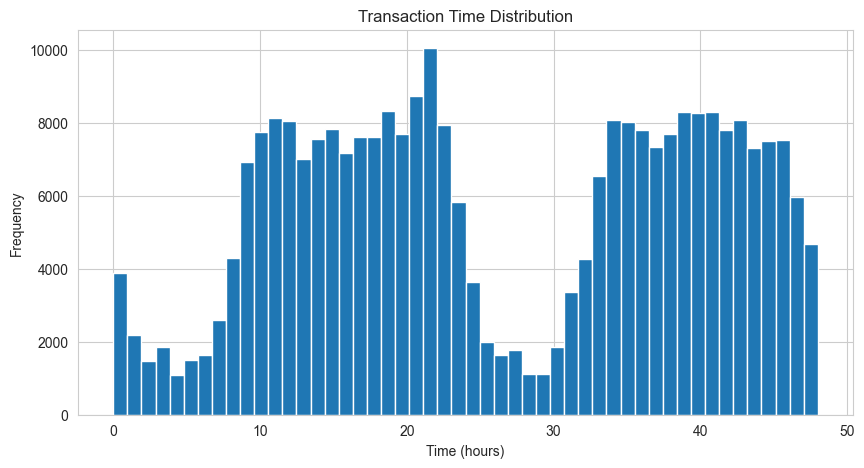

In [14]:
# ========================
# Transaction Time
# ========================

df["Time"].describe()
# ========================
# Time Distribution
# ========================

plt.figure(figsize=(10,5))

plt.hist(
    df["Time"]/ 3600,
    bins=50
)
print("Combien de transactions ont eu lieu à chaque moment des 48h couvertes par le dataset?")
plt.title(
    "Transaction Time Distribution"
)

plt.xlabel("Time (hours)")

plt.ylabel("Frequency")

plt.show()

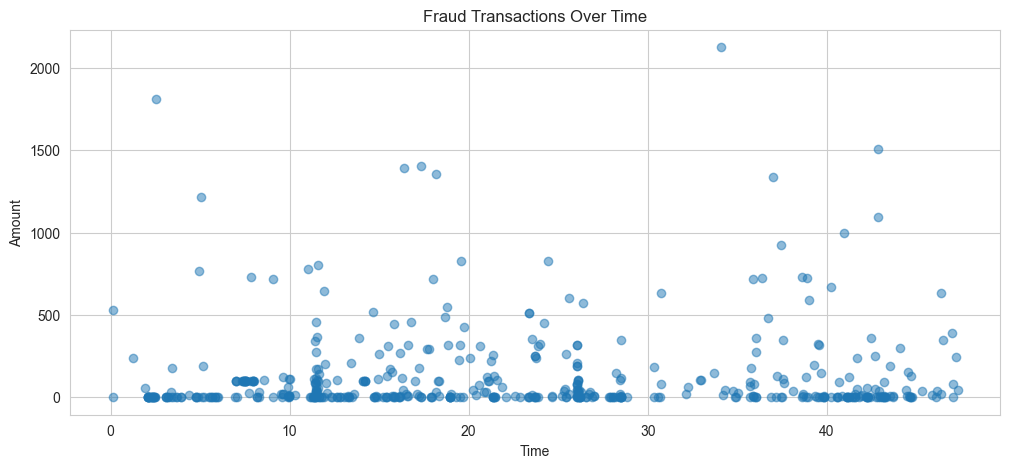

27


In [22]:
# ========================
# Fraud Transactions Over Time
# ========================

plt.figure(figsize=(12,5))

plt.scatter(
    
    df[df["Class"] == 1]["Time"]/3600,
    
    df[df["Class"] == 1]["Amount"],
    
    alpha=0.5
)

plt.title(
    "Fraud Transactions Over Time"
)

plt.xlabel("Time")

plt.ylabel("Amount")

plt.show()
print(((df["Amount"] == 0) & (df["Class"] == 1)).sum())

In [23]:
# ========================
# Log Transaction Amount
# ========================

df["LOG_AMOUNT"] = np.log1p(
    df["Amount"]
)

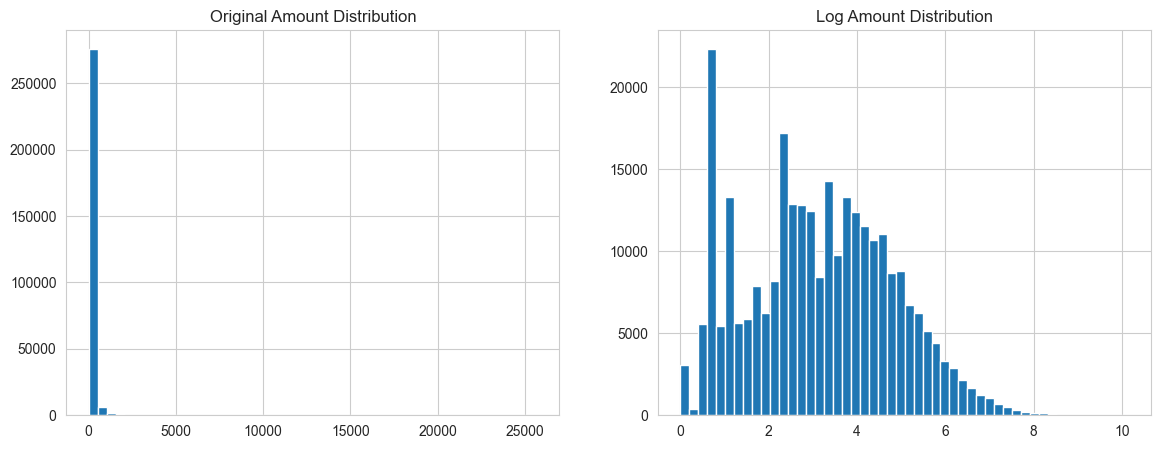

In [24]:
# ========================
# Compare Amount Distributions
# ========================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

axes[0].hist(
    df["Amount"],
    bins=50
)

axes[0].set_title(
    "Original Amount Distribution"
)

axes[1].hist(
    df["LOG_AMOUNT"],
    bins=50
)

axes[1].set_title(
    "Log Amount Distribution"
)

plt.show()

In [25]:
# ========================
# Fraud Amount Statistics
# ========================

fraud_amount_stats = (
    
    df.groupby("Class")["Amount"]
    .describe()
)

display(fraud_amount_stats)

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0000,88.2910,250.1051,0.0000,5.6500,22.0000,77.0500,25691.1600
1,492.0000,122.2113,256.6833,0.0000,1.0000,9.2500,105.8900,2125.8700


In [26]:
# ========================
# High Amount Feature
# ========================

high_amount_threshold = (
    
    df["Amount"]
    .quantile(0.95)
)

df["HIGH_AMOUNT_FLAG"] = (
    
    df["Amount"]
    >
    high_amount_threshold
    
).astype(int)

print(
    f"High amount threshold: "
    f"{high_amount_threshold:.2f}"
)

High amount threshold: 365.00


In [28]:
# ========================
# Fraud Rate Analysis
# ========================

fraud_rate_high_amount = (
    
    df.groupby("HIGH_AMOUNT_FLAG")["Class"]
    .mean()
    * 100
)

print(fraud_rate_high_amount)

HIGH_AMOUNT_FLAG
0   0.1659
1   0.3021
Name: Class, dtype: float64


In [32]:
# ========================
# Correlation with Fraud
# ========================

fraud_corr = (
    
    df.corr()["Class"]
    .sort_values(ascending=False)
)

print(fraud_corr.head(15))

Class              1.0000
V11                0.1549
V4                 0.1334
V2                 0.0913
V21                0.0404
V19                0.0348
V20                0.0201
V8                 0.0199
V27                0.0176
V28                0.0095
HIGH_AMOUNT_FLAG   0.0071
Amount             0.0056
V26                0.0045
V25                0.0033
V22                0.0008
Name: Class, dtype: float64


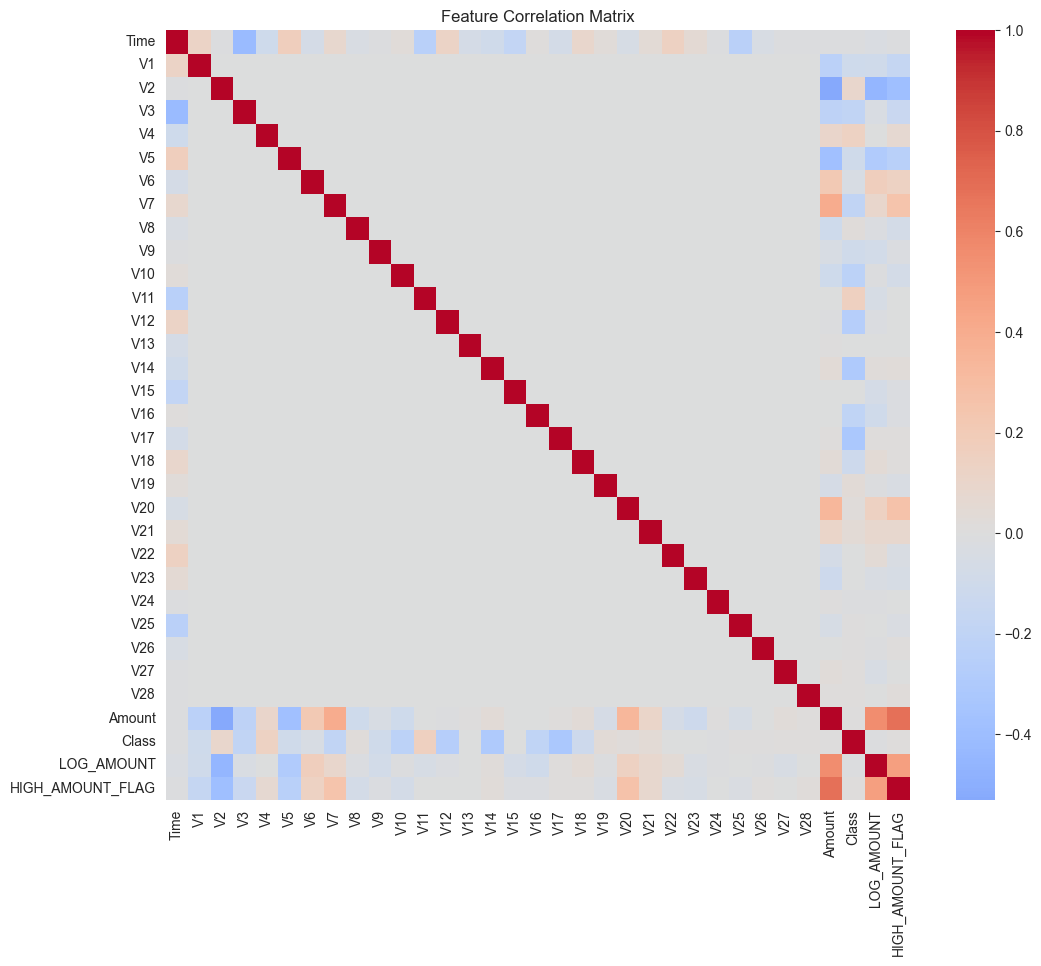

In [30]:
# ========================
# Correlation Heatmap
# ========================

plt.figure(figsize=(12,10))

sns.heatmap(
    
    df.corr(),
    
    cmap="coolwarm",
    
    center=0
)

plt.title(
    "Feature Correlation Matrix"
)

plt.show()

## Key Findings

### Severe Class Imbalance
Fraudulent transactions represent only a very small proportion of the dataset (~0.17%), confirming that fraud detection is a highly imbalanced classification problem.

### Transaction Amount Patterns
Transaction amounts are strongly skewed. A logarithmic transformation (`LOG_AMOUNT`) was applied to stabilize the distribution and improve model learning.

### Fraudulent Transaction Behavior
Fraudulent transactions occur across different time periods and transaction amounts:
- many fraud cases involve very small amounts
- some frauds correspond to extremely large transactions

This suggests that fraud cannot be identified using transaction amount alone.

### High Amount Transactions
A new feature (`HIGH_AMOUNT_FLAG`) was engineered using the 95th percentile transaction threshold.

Results showed:
- normal transactions: ~0.166% fraud rate
- high amount transactions: ~0.302% fraud rate

This indicates that high-value transactions are significantly more likely to be fraudulent.

### Feature Correlation
Correlation analysis highlighted that several anonymized PCA features (V1–V28) contain meaningful fraud-related signal.

The engineered amount-based features also showed relevant relationships with fraudulent activity.


# 3. Train/Test Split & Preprocessing

This section:
- prepares train and test datasets
- handles severe class imbalance
- scales numerical features
- prepares supervised and anomaly detection models

In [33]:
# ========================
# Train/Test Imports
# ========================

from sklearn.model_selection import (
    train_test_split
)

from sklearn.preprocessing import (
    StandardScaler
)

In [34]:
# ========================
# Features & Target
# ========================

X = df.drop(
    columns=["Class"]
)

y = df["Class"]

print(
    f"Feature Shape: {X.shape}"
)

print(
    f"Target Shape: {y.shape}"
)

Feature Shape: (284807, 32)
Target Shape: (284807,)


In [35]:
# ========================
# Stratified Split
# ========================

X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    
    test_size=0.2,
    
    stratify=y,
    
    random_state=RANDOM_STATE
)

print(
    f"Train Shape: {X_train.shape}"
)

print(
    f"Test Shape: {X_test.shape}"
)

Train Shape: (227845, 32)
Test Shape: (56962, 32)


In [36]:
# ========================
# Fraud Distribution Check
# ========================

print(
    "Train Fraud Rate:"
)

print(
    y_train.value_counts(normalize=True) * 100
)

print("\nTest Fraud Rate:")

print(
    y_test.value_counts(normalize=True) * 100
)


Train Fraud Rate:
Class
0   99.8271
1    0.1729
Name: proportion, dtype: float64

Test Fraud Rate:
Class
0   99.8280
1    0.1720
Name: proportion, dtype: float64


In [37]:
# ========================
# Feature Scaling
# ========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print(
    "Feature scaling completed."
)

Feature scaling completed.


In [38]:
# ========================
# Scale Verification
# ========================

print(
    f"Scaled Train Shape: "
    f"{X_train_scaled.shape}"
)

print(
    f"Scaled Test Shape: "
    f"{X_test_scaled.shape}"
)

Scaled Train Shape: (227845, 32)
Scaled Test Shape: (56962, 32)


In [39]:
# ========================
# Fraud Class Weight
# ========================

scale_pos_weight = (
    
    y_train.value_counts()[0]
    
    /
    
    y_train.value_counts()[1]
)

print(
    f"Scale Pos Weight: "
    f"{scale_pos_weight:.2f}"
)

Scale Pos Weight: 577.29


In [40]:
# ========================
# Modeling Imports
# ========================

from xgboost import XGBClassifier

from sklearn.metrics import (
    
    classification_report,
    
    confusion_matrix,
    
    roc_auc_score,
    
    average_precision_score,
    
    precision_score,
    
    recall_score,
    
    f1_score
)

In [41]:
# ========================
# Fraud XGBoost Model
# ========================

fraud_xgb = XGBClassifier(
    
    n_estimators=300,
    
    learning_rate=0.05,
    
    max_depth=6,
    
    subsample=0.8,
    
    colsample_bytree=0.8,
    
    scale_pos_weight=scale_pos_weight,
    
    objective="binary:logistic",
    
    eval_metric="aucpr",
    
    random_state=RANDOM_STATE,
    
    n_jobs=-1
)

print(
    "Fraud XGBoost model created."
)

Fraud XGBoost model created.


In [42]:
# ========================
# Train Fraud Model
# ========================

fraud_xgb.fit(
    
    X_train_scaled,
    y_train
)

print(
    "Fraud model trained."
)

Fraud model trained.


In [43]:
# ========================
# Fraud Predictions
# ========================

y_test_pred = fraud_xgb.predict(
    X_test_scaled
)

y_test_proba = (
    
    fraud_xgb
    .predict_proba(X_test_scaled)[:, 1]
)

In [44]:
# ========================
# Fraud Metrics
# ========================

fraud_auc = roc_auc_score(
    
    y_test,
    y_test_proba
)

fraud_pr_auc = average_precision_score(
    
    y_test,
    y_test_proba
)

fraud_recall = recall_score(
    
    y_test,
    y_test_pred
)

fraud_precision = precision_score(
    
    y_test,
    y_test_pred
)

fraud_f1 = f1_score(
    
    y_test,
    y_test_pred
)

print(f"ROC-AUC:  {fraud_auc:.4f}")

print(f"PR-AUC:   {fraud_pr_auc:.4f}")

print(f"Recall:   {fraud_recall:.4f}")

print(f"Precision:{fraud_precision:.4f}")

print(f"F1 Score: {fraud_f1:.4f}")

ROC-AUC:  0.9823
PR-AUC:   0.8766
Recall:   0.8265
Precision:0.8438
F1 Score: 0.8351


In [45]:
# ========================
# Classification Report
# ========================

print(
    classification_report(
        
        y_test,
        
        y_test_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



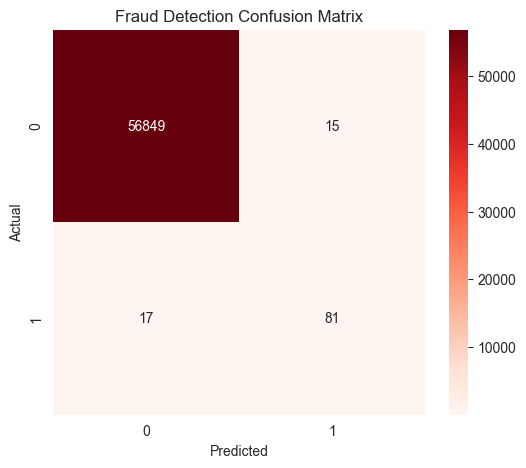

In [46]:
# ========================
# Confusion Matrix
# ========================

cm = confusion_matrix(
    
    y_test,
    y_test_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    
    cm,
    
    annot=True,
    
    fmt="d",
    
    cmap="Reds"
)

plt.title(
    "Fraud Detection Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [47]:
# ========================
# Fraud Detection Counts
# ========================

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives:  {tn}")

print(f"False Positives: {fp}")

print(f"False Negatives: {fn}")

print(f"True Positives:  {tp}")

True Negatives:  56849
False Positives: 15
False Negatives: 17
True Positives:  81


## Key Objectives


## Modeling Approach
An XGBoost classifier was trained using:
- scaled transaction features
- imbalance-aware class weighting (`scale_pos_weight`)
- fraud-oriented evaluation metrics

## Model Performance

### Interpretation

The model:
- successfully detected the majority of fraudulent transactions
- generated very few false alerts
- maintained a strong balance between fraud recall and precision

## Conclusion

The supervised fraud detection model demonstrated strong predictive performance despite the severe imbalance of the dataset.

The system is now ready for:
- threshold optimization
- anomaly detection
- explainable fraud monitoring
- production-style fraud alerting

# 5. Fraud Threshold Optimization

This section optimizes the fraud detection threshold.

Objectives:
- maximize fraud detection recall
- control false fraud alerts
- optimize operational fraud monitoring

In [48]:
# ========================
# Threshold Evaluation
# ========================

def evaluate_fraud_threshold(
    
    y_true,
    
    y_proba,
    
    threshold
):
    
    y_pred = (
        
        y_proba >= threshold
        
    ).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(
        
        y_true,
        y_pred
        
    ).ravel()
    
    recall = recall_score(
        
        y_true,
        y_pred
    )
    
    precision = precision_score(
        
        y_true,
        y_pred
    )
    
    f1 = f1_score(
        
        y_true,
        y_pred
    )
    
    return {
        
        "threshold": threshold,
        
        "recall": recall,
        
        "precision": precision,
        
        "f1": f1,
        
        "fp": fp,
        
        "fn": fn,
        
        "tp": tp
    }

In [55]:
# ========================
# Threshold Analysis
# ========================

thresholds = np.arange(
    
    0.10,
    0.96,
    0.05
)

fraud_threshold_results = []

for threshold in thresholds:
    
    metrics = evaluate_fraud_threshold(
        
        y_test,
        
        y_test_proba,
        
        threshold
    )
    
    fraud_threshold_results.append(
        metrics
    )

fraud_threshold_df = pd.DataFrame(
    fraud_threshold_results
)


In [56]:
# ========================
# Threshold Summary
# ========================

print(
    "\nFraud Threshold Analysis:\n"
)

for _, row in fraud_threshold_df.iterrows():
    
    print(
        f"Threshold {row['threshold']:.2f} │ "
        f"Recall {row['recall']:.2%} │ "
        f"Precision {row['precision']:.2%} │ "
        f"FN {int(row['fn'])} │ "
        f"FP {int(row['fp'])}"
    )


Fraud Threshold Analysis:

Threshold 0.10 │ Recall 87.76% │ Precision 65.65% │ FN 12 │ FP 45
Threshold 0.15 │ Recall 87.76% │ Precision 76.11% │ FN 12 │ FP 27
Threshold 0.20 │ Recall 84.69% │ Precision 78.30% │ FN 15 │ FP 23
Threshold 0.25 │ Recall 84.69% │ Precision 80.58% │ FN 15 │ FP 20
Threshold 0.30 │ Recall 84.69% │ Precision 81.37% │ FN 15 │ FP 19
Threshold 0.35 │ Recall 83.67% │ Precision 82.83% │ FN 16 │ FP 17
Threshold 0.40 │ Recall 82.65% │ Precision 83.51% │ FN 17 │ FP 16
Threshold 0.45 │ Recall 82.65% │ Precision 83.51% │ FN 17 │ FP 16
Threshold 0.50 │ Recall 82.65% │ Precision 84.38% │ FN 17 │ FP 15
Threshold 0.55 │ Recall 82.65% │ Precision 84.38% │ FN 17 │ FP 15
Threshold 0.60 │ Recall 82.65% │ Precision 84.38% │ FN 17 │ FP 15
Threshold 0.65 │ Recall 82.65% │ Precision 84.38% │ FN 17 │ FP 15
Threshold 0.70 │ Recall 82.65% │ Precision 85.26% │ FN 17 │ FP 14
Threshold 0.75 │ Recall 82.65% │ Precision 88.04% │ FN 17 │ FP 11
Threshold 0.80 │ Recall 82.65% │ Precision 89.01

## Operational Tradeoff

### Low Thresholds
Advantages:
- maximum fraud detection
- fewer missed fraud cases

Disadvantages:
- more legitimate transactions flagged

### High Thresholds
Advantages:
- fewer false alerts
- improved customer experience

Disadvantages:
- more fraud cases missed

## Recommended Threshold

A threshold between 0.35 and 0.50 provides a strong operational balance:
- high fraud recall
- strong precision
- limited false positives

The fraud detection system is now operationally usable for transaction monitoring.

# 6. Isolation Forest — Anomaly Detection

This section develops an anomaly detection system using Isolation Forest.

Objectives:
- detect suspicious transaction behavior
- identify unknown fraud patterns
- complement supervised fraud detection
- improve fraud monitoring robustness

In [57]:
# ========================
# Isolation Forest Import
# ========================

from sklearn.ensemble import (
    IsolationForest
)

In [ ]:
# ========================
# Isolation Forest Model
# ========================

iso_forest = IsolationForest(
    
    n_estimators=200,
    
    contamination=0.002, #Approximate fraud rate (0.17% fraud)
    
    random_state=RANDOM_STATE,
    
    n_jobs=-1
)

print(
    "Isolation Forest created."
)

Isolation Forest created.


In [59]:
# ========================
# Train on Normal Transactions
# ========================

X_train_normal = (
    
    X_train_scaled[
        
        y_train == 0
    ]
)

iso_forest.fit(
    
    X_train_normal
)

print(
    "Isolation Forest trained."
)

Isolation Forest trained.


In [60]:
# ========================
# Isolation Forest Predictions
# ========================

iso_predictions = (
    
    iso_forest.predict(
        X_test_scaled
    )
)

# Convert:
# -1 = anomaly/fraud
#  1 = normal

iso_predictions = np.where(
    
    iso_predictions == -1,
    
    1,
    
    0
)

In [61]:
# ========================
# Isolation Forest Metrics
# ========================

iso_recall = recall_score(
    
    y_test,
    
    iso_predictions
)

iso_precision = precision_score(
    
    y_test,
    
    iso_predictions
)

iso_f1 = f1_score(
    
    y_test,
    
    iso_predictions
)

print(f"Recall:   {iso_recall:.4f}")

print(f"Precision:{iso_precision:.4f}")

print(f"F1 Score: {iso_f1:.4f}")

Recall:   0.2347
Precision:0.1586
F1 Score: 0.1893


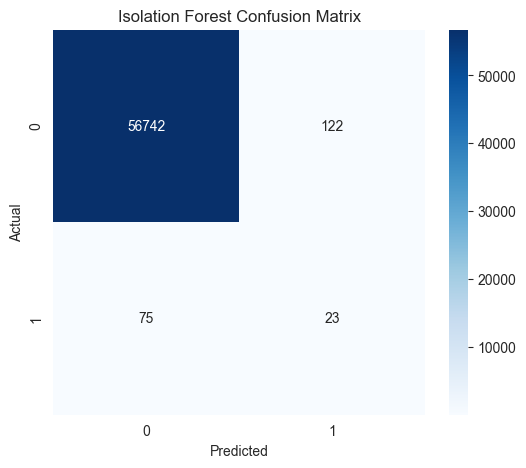

In [62]:
# ========================
# Isolation Forest Confusion Matrix
# ========================

iso_cm = confusion_matrix(
    
    y_test,
    
    iso_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    
    iso_cm,
    
    annot=True,
    
    fmt="d",
    
    cmap="Blues"
)

plt.title(
    "Isolation Forest Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [63]:
# ========================
# Model Comparison
# ========================

comparison_df = pd.DataFrame({

    "Model": [
        
        "XGBoost",
        
        "Isolation Forest"
    ],
    
    "Recall": [
        
        fraud_recall,
        
        iso_recall
    ],
    
    "Precision": [
        
        fraud_precision,
        
        iso_precision
    ],
    
    "F1 Score": [
        
        fraud_f1,
        
        iso_f1
    ]
})

display(comparison_df)

,Model,Recall,Precision,F1 Score
0,XGBoost,0.8265,0.8438,0.8351
1,Isolation Forest,0.2347,0.1586,0.1893


The supervised XGBoost model detects known fraud patterns, while Isolation Forest provides anomaly-based monitoring for emerging or previously unseen fraudulent behaviors.

# Isolation Forest Findings

Isolation Forest successfully identified anomalous transaction behavior without using fraud labels.

Key observations:
- anomaly detection complements supervised fraud modeling
- the model can identify unusual transaction patterns
- unsupervised methods are valuable for emerging fraud scenarios

# 7. SHAP Explainability — Fraud Detection

This section explains fraud predictions using SHAP values.

Objectives:
- identify key fraud drivers
- explain suspicious transaction patterns
- improve fraud alert interpretability
- support explainable AI monitoring

In [64]:
import shap
# ========================
# SHAP Explainer
# ========================

fraud_explainer = shap.TreeExplainer(
    
    fraud_xgb
)

fraud_shap_values = (
    
    fraud_explainer.shap_values(
        
        X_test_scaled
    )
)

print(
    "Fraud SHAP values computed."
)

Fraud SHAP values computed.


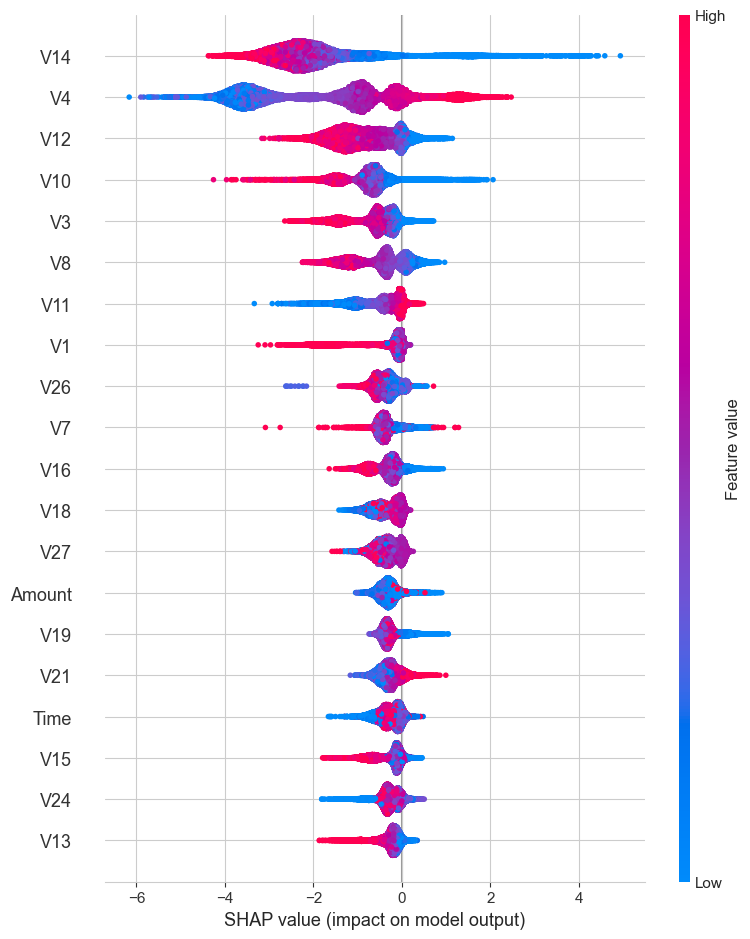

In [65]:
# ========================
# Feature Names
# ========================

feature_names = X.columns.tolist()
# ========================
# SHAP Summary Plot
# ========================

shap.summary_plot(
    
    fraud_shap_values,
    
    X_test_scaled,
    
    feature_names=feature_names
)

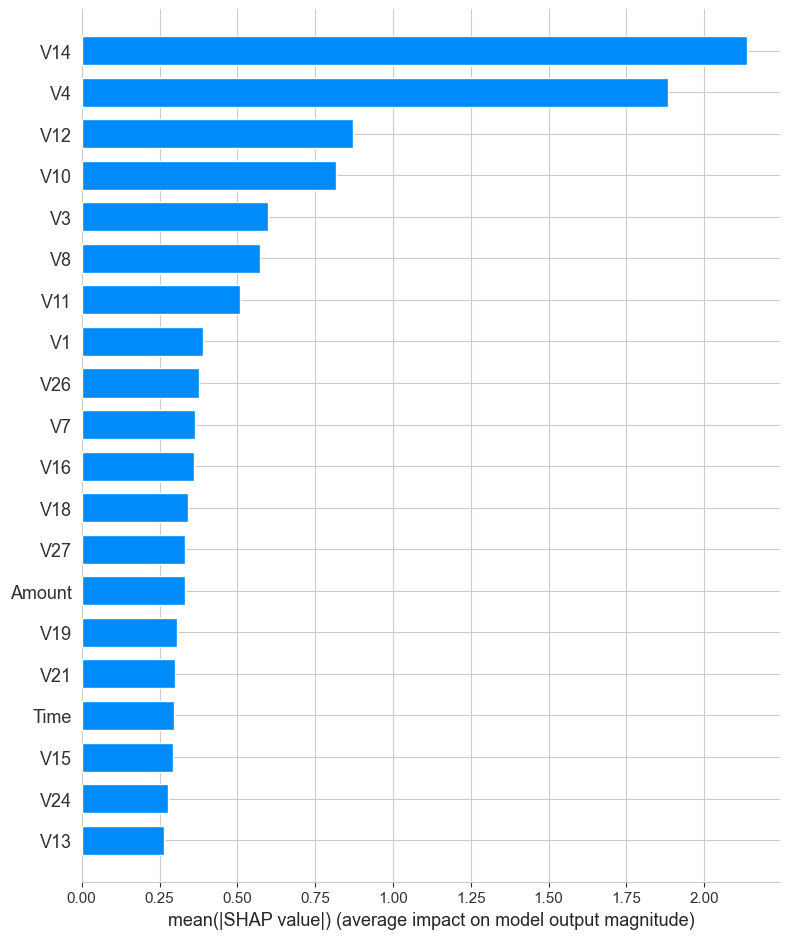

In [66]:
# ========================
# SHAP Bar Plot
# ========================

shap.summary_plot(
    
    fraud_shap_values,
    
    X_test_scaled,
    
    feature_names=feature_names,
    
    plot_type="bar"
)

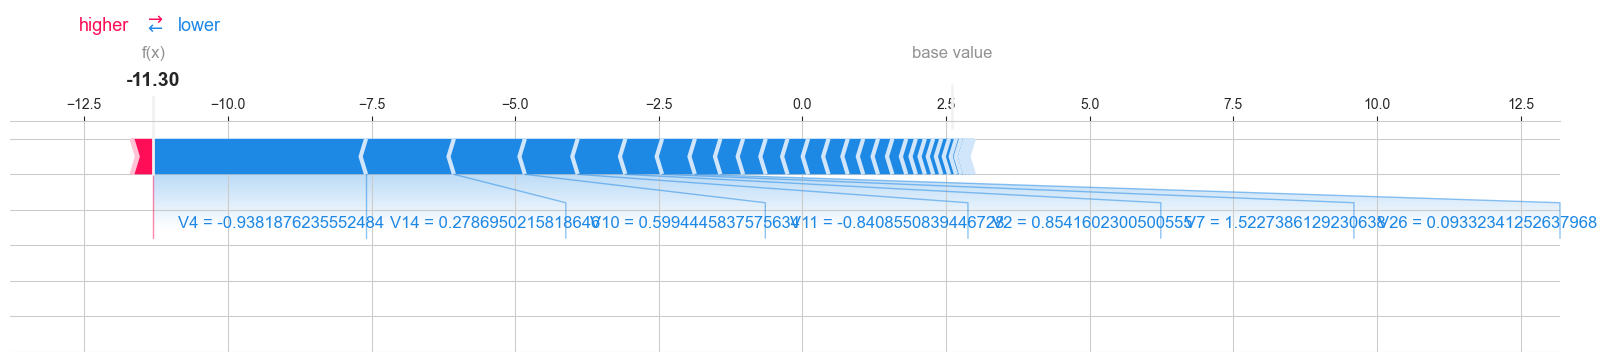

In [67]:
# ========================
# Single Fraud Explanation
# ========================

fraud_index = 0

shap.force_plot(
    
    fraud_explainer.expected_value,
    
    fraud_shap_values[fraud_index],
    
    X_test_scaled[fraud_index],
    
    feature_names=feature_names,
    
    matplotlib=True
)

In [68]:
# ========================
# Find Fraud Example
# ========================

fraud_cases = np.where(
    
    y_test.values == 1
)[0]

print(
    f"Number of fraud cases: "
    f"{len(fraud_cases)}"
)

fraud_cases[:10]

Number of fraud cases: 98


array([ 840, 1146, 3287, 4276, 5077, 5453, 7164, 7299, 7337, 9036])

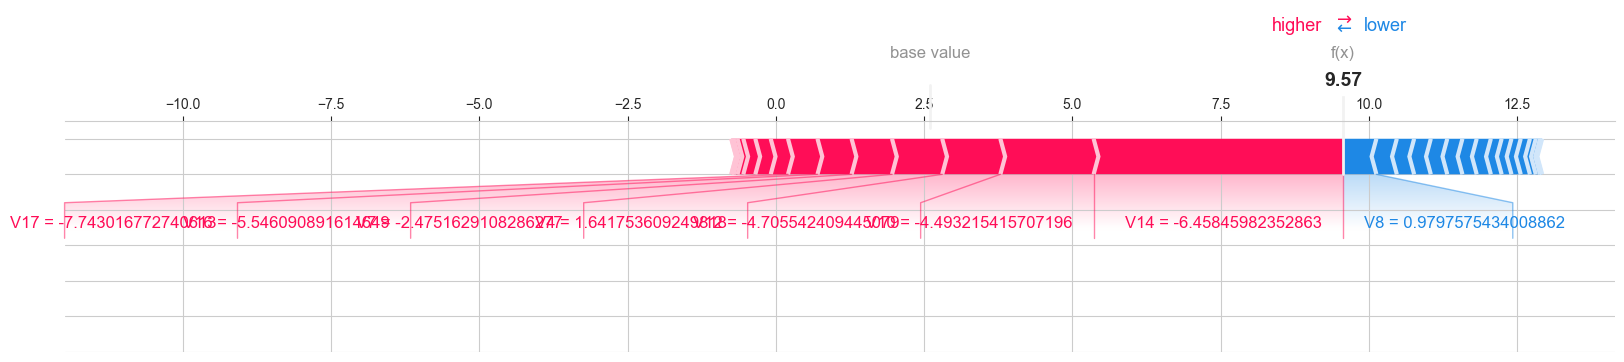

In [69]:
# ========================
# Explain Real Fraud
# ========================

fraud_index = fraud_cases[0]

shap.force_plot(
    
    fraud_explainer.expected_value,
    
    fraud_shap_values[fraud_index],
    
    X_test_scaled[fraud_index],
    
    feature_names=feature_names,
    
    matplotlib=True
)

In [70]:
# ========================
# Mean SHAP Importance
# ========================

shap_importance = pd.DataFrame({

    "Feature": feature_names,
    
    "Importance": np.abs(
        fraud_shap_values
    ).mean(axis=0)
})

shap_importance = (
    
    shap_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

display(
    shap_importance.head(30)
)

,Feature,Importance
14,V14,2.1368
4,V4,1.8849
12,V12,0.8718
10,V10,0.8178
3,V3,0.5984
8,V8,0.5723
11,V11,0.5095
1,V1,0.3903
26,V26,0.3759
7,V7,0.3647


# SHAP Explainability Findings

SHAP analysis identified the main drivers of fraudulent transaction predictions.

Key observations:
- PCA-transformed variables (especially V14, V4, V12, and V10) dominate fraud detection performance
- transaction features such as Amount and Time also contribute to fraud risk
- engineered features had lower importance because much of the signal is already captured by PCA components

SHAP explanations improved model interpretability by showing:
- which features increase fraud probability
- why specific transactions are flagged as suspicious
- how the fraud detection system makes decisions

The fraud detection pipeline now supports explainable and operational fraud monitoring.

# Bonus — LightGBM Fraud Detection

In [71]:
# ========================
# LightGBM Import
# ========================

from lightgbm import (
    LGBMClassifier
)

In [73]:
# ========================
# LightGBM Fraud Model
# ========================

fraud_lgbm = LGBMClassifier(
    
    n_estimators=300,
    
    learning_rate=0.05,
    
    max_depth=6,
    
    subsample=0.8,
    
    colsample_bytree=0.8,
    
    scale_pos_weight=scale_pos_weight,
    
    objective="binary",
    
    random_state=RANDOM_STATE,
    
    n_jobs=-1
)

print(
    "LightGBM model created."
)

LightGBM model created.


In [74]:
# ========================
# Train LightGBM
# ========================

fraud_lgbm.fit(
    
    X_train_scaled,
    
    y_train
)

print(
    "LightGBM model trained."
)

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020541 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7908
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [75]:
# ========================
# LightGBM Predictions
# ========================

lgbm_pred = fraud_lgbm.predict(
    
    X_test_scaled
)

lgbm_proba = (
    
    fraud_lgbm
    .predict_proba(X_test_scaled)[:,1]
)

In [76]:
# ========================
# LightGBM Metrics
# ========================

lgbm_auc = roc_auc_score(
    
    y_test,
    
    lgbm_proba
)

lgbm_pr_auc = average_precision_score(
    
    y_test,
    
    lgbm_proba
)

lgbm_recall = recall_score(
    
    y_test,
    
    lgbm_pred
)

lgbm_precision = precision_score(
    
    y_test,
    
    lgbm_pred
)

lgbm_f1 = f1_score(
    
    y_test,
    
    lgbm_pred
)

print(f"ROC-AUC:  {lgbm_auc:.4f}")

print(f"PR-AUC:   {lgbm_pr_auc:.4f}")

print(f"Recall:   {lgbm_recall:.4f}")

print(f"Precision:{lgbm_precision:.4f}")

print(f"F1 Score: {lgbm_f1:.4f}")

ROC-AUC:  0.9106
PR-AUC:   0.0249
Recall:   0.8776
Precision:0.0270
F1 Score: 0.0523


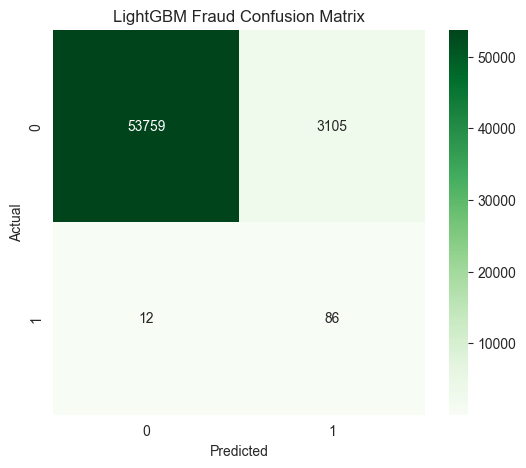

In [77]:
# ========================
# LightGBM Confusion Matrix
# ========================

lgbm_cm = confusion_matrix(
    
    y_test,
    
    lgbm_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    
    lgbm_cm,
    
    annot=True,
    
    fmt="d",
    
    cmap="Greens"
)

plt.title(
    "LightGBM Fraud Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [78]:
# ========================
# Fraud Model Comparison
# ========================

fraud_model_comparison = pd.DataFrame({

    "Model": [
        
        "XGBoost",
        
        "LightGBM",
        
        "Isolation Forest"
    ],
    
    "Recall": [
        
        fraud_recall,
        
        lgbm_recall,
        
        iso_recall
    ],
    
    "Precision": [
        
        fraud_precision,
        
        lgbm_precision,
        
        iso_precision
    ],
    
    "F1 Score": [
        
        fraud_f1,
        
        lgbm_f1,
        
        iso_f1
    ]
})

display(
    fraud_model_comparison
)

,Model,Recall,Precision,F1 Score
0,XGBoost,0.8265,0.8438,0.8351
1,LightGBM,0.8776,0.0270,0.0523
2,Isolation Forest,0.2347,0.1586,0.1893


# LightGBM Comparison Findings

LightGBM achieved higher fraud recall than XGBoost but generated an extremely large number of false positives.

Although the model detected most fraudulent transactions, the very low precision indicates that many legitimate transactions were incorrectly classified as fraud.

In contrast, XGBoost achieved a significantly better balance between fraud detection recall and alert precision, making it more operationally suitable for fraud monitoring.

This highlights the importance of balancing fraud detection performance with customer experience and false alert management.